# Time Series Project

In [1]:
# Step 1: Read the data from the CSV file Download CSV file into a DataFrame called gold.
import pandas as pd
gold = pd.read_csv('gold.csv')

In [2]:
gold.head()

,Date,Price
0,1950-01,34.73
1,1950-02,34.73
2,1950-03,34.73
3,1950-04,34.73
4,1950-05,34.73


In [3]:
# Step 2: Run the info() method, and note the data types of the two columns.
gold.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 847 entries, 0 to 846
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    847 non-null    object 
 1   Price   847 non-null    float64
dtypes: float64(1), object(1)
memory usage: 13.4+ KB


In [4]:
# Step 3: Convert the Date column to the DateTime data type. Then, display the first five rows of data, and note that the dates are for the first of each month starting in 1950.
gold['Date'] = pd.to_datetime(gold['Date'], format = '%Y-%m')
gold.head()

,Date,Price
0,1950-01-01,34.73
1,1950-02-01,34.73
2,1950-03-01,34.73
3,1950-04-01,34.73
4,1950-05-01,34.73


<Axes: title={'center': 'Gold Price Over Time'}, xlabel='Date', ylabel='Price in USD'>

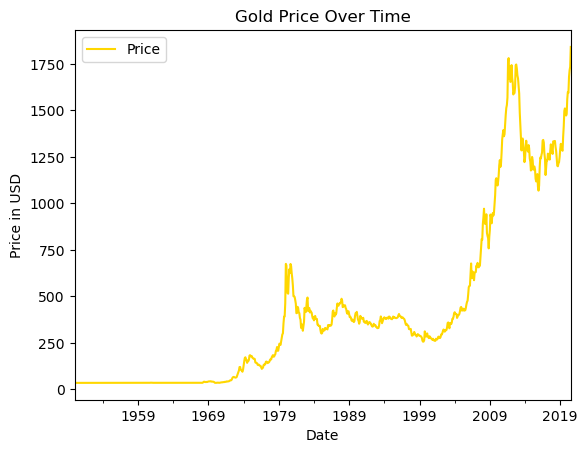

In [5]:
# Step 4: Plot the data with a Pandas line plot.
gold.plot(x = 'Date', y = 'Price', color = 'gold', title = 'Gold Price Over Time', xlabel = 'Date', ylabel = 'Price in USD', legend = True)

In [6]:
# Step 5: Index the data on the Date column. Then, generate time periods for the first day of each year from 1950 to 2020.
gold.set_index('Date', inplace=True)
year_periods = pd.date_range(start='1950-01-01', end='2020-12-31', freq='YS')
year_periods

DatetimeIndex(['1950-01-01', '1951-01-01', '1952-01-01', '1953-01-01',
               '1954-01-01', '1955-01-01', '1956-01-01', '1957-01-01',
               '1958-01-01', '1959-01-01', '1960-01-01', '1961-01-01',
               '1962-01-01', '1963-01-01', '1964-01-01', '1965-01-01',
               '1966-01-01', '1967-01-01', '1968-01-01', '1969-01-01',
               '1970-01-01', '1971-01-01', '1972-01-01', '1973-01-01',
               '1974-01-01', '1975-01-01', '1976-01-01', '1977-01-01',
               '1978-01-01', '1979-01-01', '1980-01-01', '1981-01-01',
               '1982-01-01', '1983-01-01', '1984-01-01', '1985-01-01',
               '1986-01-01', '1987-01-01', '1988-01-01', '1989-01-01',
               '1990-01-01', '1991-01-01', '1992-01-01', '1993-01-01',
               '1994-01-01', '1995-01-01', '1996-01-01', '1997-01-01',
               '1998-01-01', '1999-01-01', '2000-01-01', '2001-01-01',
               '2002-01-01', '2003-01-01', '2004-01-01', '2005-01-01',
      

In [7]:
# Step 6: Reindex the data using the new time periods, and display the first five rows again to see that there is just one row for each year.
gold_reindexed = gold.reindex(year_periods)
gold_reindexed.head()

,Price
1950-01-01,34.73
1951-01-01,34.72
1952-01-01,34.49
1953-01-01,34.88
1954-01-01,34.86


<Axes: title={'center': 'Annual Gold Price on January 1st (1950-2020)'}, xlabel='Date', ylabel='Price in USD'>

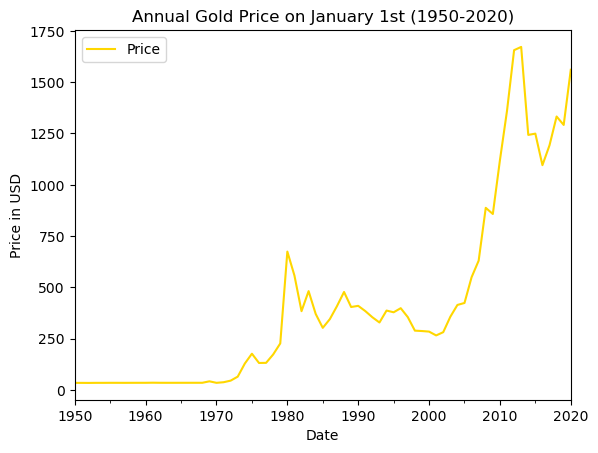

In [8]:
# Step 7: Plot the reindexed data with a Pandas line plot.
gold_reindexed.plot(color = 'gold', title = 'Annual Gold Price on January 1st (1950-2020)', xlabel = 'Date', ylabel = 'Price in USD', legend = True)

<Axes: title={'center': 'Quarterly Average Gold Price (1950-2020)'}, xlabel='Date (Quaterly)', ylabel='Price in USD'>

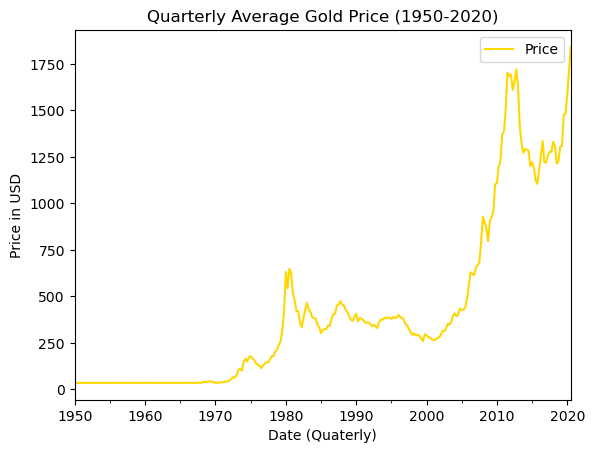

In [9]:
# Step 8: Resample the data to a quarterly frequency and plot the data again.
gold_quarterly = gold.resample('Q').mean()
gold_quarterly.plot(color = 'gold', title = 'Quarterly Average Gold Price (1950-2020)', xlabel = 'Date (Quaterly)', ylabel = 'Price in USD', legend = True)

<Axes: title={'center': 'Yearly Average Gold Price (1950-2020)'}, xlabel='Date (Yearly)', ylabel='Price in USD'>

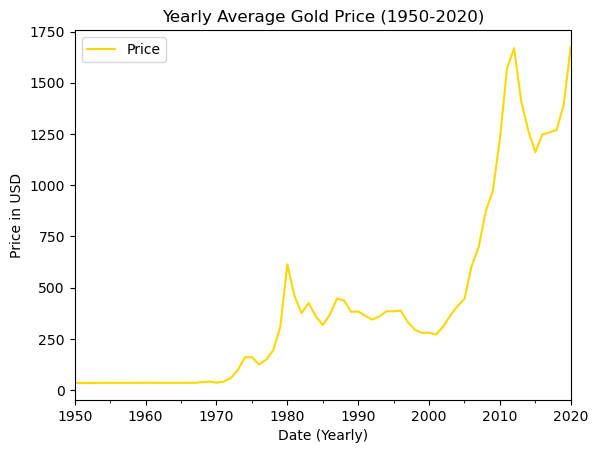

In [10]:
# Step 9: Resample the data to a yearly frequency and plot the data one more time.
gold_yearly = gold.resample('Y').mean()
gold_yearly.plot(color = 'gold', title = 'Yearly Average Gold Price (1950-2020)', xlabel = 'Date (Yearly)', ylabel = 'Price in USD', legend = True)

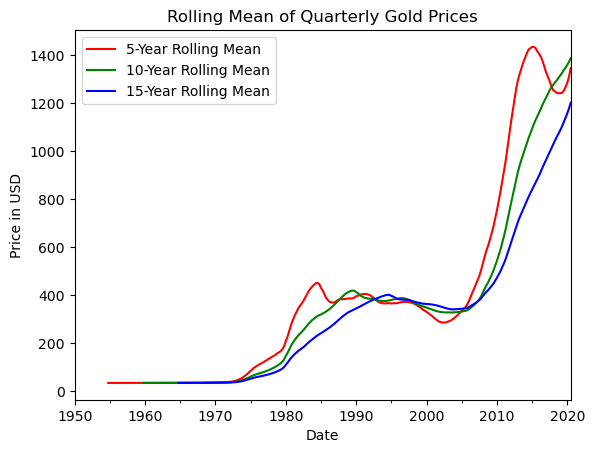

In [11]:
# Step 10: Plot the rolling mean for the data using a Pandas line plot. Experiment with different values for the window parameter.
ax = gold_quarterly['Price'].rolling(window = 20).mean().plot(label = '5-Year Rolling Mean', color = 'red', title = 'Rolling Mean of Quarterly Gold Prices')
gold_quarterly['Price'].rolling(window = 40).mean().plot(ax = ax, label = '10-Year Rolling Mean', color = 'green')
gold_quarterly['Price'].rolling(window = 60).mean().plot(ax = ax, label = '15-Year Rolling Mean', color = 'blue')

ax.set_xlabel('Date')
ax.set_ylabel('Price in USD')
ax.legend()